# Описание проекта

**Заказчик** — ***Министерство культуры Российской Федерации.***

**Цель исследования:**

- *Изучить рынок российского кинопроката и выявить текущие тренды.*
- *Уделить внимание фильмам, которые получили государственную поддержку.* 
- *Ответить на вопрос, насколько такие фильмы интересны зрителю.*

Данные взяты из опубликованных на портале открытых данных Министерства культуры. 

**Набор данных содержит:**

- информацию о прокатных удостоверениях
- информацию о сборах и государственной поддержке фильмов
- информацию с сайта КиноПоиск.

## Исследование данных о российском кинопрокате

Объединяем данные таким образом, чтобы все объекты из датасета `mkrf_movies` обязательно вошли в получившийся датафрейм.

In [2]:
# импорт библиотеки pandas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

C:\Users\yerke\Anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


In [3]:
# чтение файлов с данными и сохранение в df
df_movies = pd.read_csv('data/mkrf_movies.csv')
df_shows = pd.read_csv('data/mkrf_shows.csv')

In [4]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [5]:
df_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


In [6]:
# Удаляем строку где столбец 'puNumber' равно значению 'нет'
df_movies = df_movies[df_movies['puNumber'] != 'нет'].reset_index(drop=True)

In [7]:
# Меняем тип данных на int для столбца puNumber
df_movies['puNumber'] = df_movies['puNumber'].astype('int')

In [8]:
# Показываем сколько уникальных значений в столбце puNumber
df_movies['puNumber'].nunique()

7483

В датасете `df_movies` в столбце `puNumber` 7483 уникальных значений

In [9]:
# Показываем сколько уникальных значений
df_shows['puNumber'].nunique()

3158

В датасете `df_shows` в столбце `puNumber` 3158 уникальных значений

In [10]:
# Меняем тип данных на int для столбца 'puNumber'
df_shows['puNumber'] = df_shows['puNumber'].astype('int')

In [11]:
# Соединям датафреймы
df = df_movies.merge(df_shows, on='puNumber', how='outer')

### Шаг 2. Предобработка данных

#### Шаг 2.1. Проверим типы данных

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7485 non-null   object 
 1   puNumber               7485 non-null   int32  
 2   show_start_date        7485 non-null   object 
 3   type                   7485 non-null   object 
 4   film_studio            7467 non-null   object 
 5   production_country     7483 non-null   object 
 6   director               7476 non-null   object 
 7   producer               6917 non-null   object 
 8   age_restriction        7485 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

# Описание данных

Таблица `mkrf_movies` содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений.

- `title` — название фильма;
- `puNumber` — номер прокатного удостоверения;
- `show_start_date` — дата премьеры фильма;
- `type` — тип фильма;
- `film_studio` — студия-производитель;
- `production_country` — страна-производитель;
- `director` — режиссёр;
- `producer` — продюсер;
- `age_restriction` — возрастная категория;
- `refundable_support` — объём возвратных средств государственной поддержки;
- `nonrefundable_support` — объём невозвратных средств государственной поддержки;
- `financing_source` — источник государственного финансирования;
- `budget` — общий бюджет фильма;
- `ratings` — рейтинг фильма на КиноПоиске;
- `genres` — жанр фильма.
 
Столбец budget уже включает в себя полный объём государственной поддержки. Данные в этом столбце указаны только для тех фильмов, которые получили государственную поддержку.

Таблица `mkrf_shows` содержит сведения о показах фильмов в российских кинотеатрах.

- `puNumber` — номер прокатного удостоверения;
- `box_office` — сборы в рублях.

И так, в таблице 16 столбцов. Разные типы данных имеются в столбцах — `object` (11 столбцов), `int` (1 столбец), `float` (4 столбца). Некоторые столбцы не имеет правильный тип данных, например: `show_start_date`, `ratings`. 

In [14]:
# Меняем тип данных в столбце show_start_date с object на datetime
df['show_start_date'] = pd.to_datetime(df['show_start_date'])

In [15]:
df.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7153
nonrefundable_support    7153
budget                   7153
financing_source         7153
ratings                   966
genres                    975
box_office               4327
dtype: int64

Видим что в стоблце `ratings` 966 пропусков. 

In [16]:
df[df['ratings']==0]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office


Также отсутствует фильмы с рейтингом 0.

In [17]:
# Заменяем пустые строки в столбце ratings на 0
df['ratings'].fillna(0, inplace=True)

In [18]:
# Перепроверяем столбец ratings
df.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7153
nonrefundable_support    7153
budget                   7153
financing_source         7153
ratings                     0
genres                    975
box_office               4327
dtype: int64

In [19]:
# Меняем значение с % на обычный вид который имеет большинство данных в столбце ratings
def correct_rating(value):
    if value.endswith("%"):
        value = int(value[:-1])/10
    return value

In [20]:
df['ratings'] = df['ratings'].astype('str')
df['ratings'] = df['ratings'].apply(correct_rating)

In [21]:
# Меняем тип данных в столбце ratings с object на float
df['ratings'] = df['ratings'].astype('float')

In [23]:
# Выводим на экран данные и проверяем столбец ratings 
df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


#### Шаг 2.2. Изучим пропуски в датафрейме

In [24]:
df.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7153
nonrefundable_support    7153
budget                   7153
financing_source         7153
ratings                     0
genres                    975
box_office               4327
dtype: int64

In [25]:
# Заполняем пустые строки в столбце financing_source со значением нет так как это не является источником
# государственного финансирования также этот столбец является тип данных object
df['financing_source'].fillna('нет', inplace=True)

In [26]:
# Заполняем пустые строки в столбце box_office со значением 0 так как неизвестны сборы в рублях
df['box_office'].fillna(0, inplace=True)

In [31]:
# Заполняем пустые строки в столбцах film_studio, production_country, director, producer, genres
# со значением неизвестно так как неизвестны студия-производитель, страна-производитель, режиссёр, продюсер, жанр фильма
# также эти столбцы являются тип данных object
interest_col = ['film_studio', 'production_country', 'director', 'producer', 'genres']
for column in interest_col:    
    df[column].fillna('неизвестно', inplace=True)

In [32]:
# Заполняем пустые строки в столбцах budget, nonrefundable_support, refundable_support, со значением 0 
# так как неизвестны общий бюджет фильма,  объём невозвратных и возвратных средств государственной поддержки,
# также эти столбцы являются тип данных float
interest_col = ['budget', 'nonrefundable_support', 'refundable_support']
for column in interest_col:       
    df[column].fillna(0, inplace=True)

#### Шаг 2.3. Изучим дубликаты в датафрейме

In [33]:
df.duplicated().sum()

0

Не имеются дубликаты в датасете.

In [36]:
# Удаляем столбцы 'show_start_date', 'puNumber' и делаем подсчёт дубликатов
df.drop(['show_start_date', 'puNumber'], axis=1).duplicated().sum()

484

Если удалеям столбцы `show_start_date`, `puNumber` то в данных 484 дубликатов. Но думаю не нужно удалять эти столбцы так как дата премьеры фильма важна как и номер прокатного удостоверения.

#### Шаг 2.4. Изучим категориальные значения

- Посмотрим, какая общая проблема встречается почти во всех категориальных столбцах;
- Исправим проблемные значения в поле `type`.

In [42]:
# Выводим на экран информацию про типы данных столбцов
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7485 non-null   object             
 1   puNumber               7485 non-null   int32              
 2   show_start_date        7485 non-null   datetime64[ns, UTC]
 3   type                   7485 non-null   object             
 4   film_studio            7485 non-null   object             
 5   production_country     7485 non-null   object             
 6   director               7485 non-null   object             
 7   producer               7485 non-null   object             
 8   age_restriction        7485 non-null   object             
 9   refundable_support     7485 non-null   float64            
 10  nonrefundable_support  7485 non-null   float64            
 11  budget                 7485 non-null   float64          

In [43]:
# Проверяем данные до удаления пробелов
df.head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,0.0,0.0,0.0,нет,7.2,"боевик,драма,мелодрама",0.0
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,неизвестно,«6+» - для детей старше 6 лет,0.0,0.0,0.0,нет,6.6,"драма,военный",0.0
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,неизвестно,«6+» - для детей старше 6 лет,0.0,0.0,0.0,нет,7.7,драма,0.0
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,неизвестно,«12+» - для детей старше 12 лет,0.0,0.0,0.0,нет,8.3,"мелодрама,комедия",2700.0
7,Любовь и сигареты,221074614,2014-12-29 12:00:00+00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.6,"мюзикл,мелодрама,комедия",0.0
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00+00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,0.0,0.0,0.0,нет,8.0,"комедия,криминал",0.0
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,неизвестно,«12+» - для детей старше 12 лет,0.0,0.0,0.0,нет,7.8,"мелодрама,комедия",0.0


In [44]:
# Проверяем данные в столбце title
df['title'].value_counts()

День святого Валентина_                               5
Белоснежка и охотник                                  4
Красавчик-2                                           4
Рапунцель: Запутанная история                         4
Кошмар на улице Вязов /Фильм ужасов/                  4
                                                     ..
Достали!                                              1
МУЛЬТ в кино. Выпуск № 14                             1
Стажёр                                                1
Мэхэббэт - ул йорэк эше (Любовь - это дело сердца)    1
Машины песенки. Серия "Когда цветут кактусы"          1
Name: title, Length: 6771, dtype: int64

In [45]:
# Проверяем данные в столбце type
df['type'].value_counts()

Художественный                4519
 Художественный               1389
Анимационный                   828
Прочие                         406
Документальный                 288
Научно-популярный               53
 Анимационный                    1
Музыкально-развлекательный       1
Name: type, dtype: int64

В столбце `type` имеются пробелы до и после значения 

In [48]:
# Проверяем данные в столбце film_studio
df['film_studio'].value_counts().head(10)

Киностудия "Мосфильм"                        341
ООО "Мульт в кино"                            57
Анимаккорд Лтд                                23
ООО "Мульт в кино"                            18
неизвестно                                    18
ФГУП "ТПО "Киностудия "Союзмультфильм"        16
ООО "ТаББаК"                                  15
Опус Арте                                     14
ООО "Студия анимационного кино "Мельница"     14
Р А И Синема                                  14
Name: film_studio, dtype: int64

In [49]:
# Проверяем данные в столбце film_studio
df['production_country'].value_counts().head(10)

США                     2172
Россия                  1820
СССР                     347
Франция                  301
Великобритания           257
Италия                   129
Германия                 110
США - Великобритания      88
Япония                    77
Испания                   74
Name: production_country, dtype: int64

In [50]:
# Проверяем данные в столбце director
df['director'].value_counts().head(10)

О.Семёнова          47
Стивен Содерберг    17
Д.Червяцов          17
Ридли Скотт         16
Тиль Швайгер        14
Вуди Аллен          13
Питер Джексон       13
Клинт Иствуд        13
Кевин Смит          12
Дэвид Финчер        12
Name: director, dtype: int64

In [52]:
# Проверяем данные в столбце producer
df['producer'].value_counts().head(10)

неизвестно                                       568
П.Смирнов                                         67
Олег Кузовков, Дмитрий Ловейко, Марина Ратина     28
С.Сельянов                                        18
Д.Ловейко, О.Кузовков                             17
Тони Майерс                                       11
Кевин Фейги                                       11
Джерри Брукхаймер                                 11
А.Тельнов                                         11
ООО "Продюсерский центр ЕРАЛАШ"                   10
Name: producer, dtype: int64

In [53]:
# Проверяем данные в столбце age_restriction
df['age_restriction'].value_counts()

«16+» - для детей старше 16 лет           2851
«18+» - запрещено для детей               1605
«12+» - для детей старше 12 лет           1592
«0+» - для любой зрительской аудитории     811
«6+» - для детей старше 6 лет              626
Name: age_restriction, dtype: int64

In [54]:
# Проверяем данные в столбце financing_source
df['financing_source'].value_counts()

нет                                 7153
Министерство культуры                164
Фонд кино                            146
Министерство культуры, Фонд кино      22
Name: financing_source, dtype: int64

In [56]:
# Проверяем данные в столбце genres
df['genres'].value_counts().head(10)

неизвестно                   975
драма                        476
комедия                      352
мелодрама,комедия            222
драма,мелодрама,комедия      189
драма,мелодрама              183
драма,комедия                158
триллер,драма,криминал       141
боевик,триллер,драма         140
фантастика,боевик,триллер     88
Name: genres, dtype: int64

In [57]:
# Удалеям все пробелы, которые встречаются в начале и в конце строк во всех категориальных столбцах
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].str.strip()

In [59]:
# после удаления пробелов
df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,0.0,0.0,0.0,нет,7.2,"боевик,драма,мелодрама",0.0
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,неизвестно,«6+» - для детей старше 6 лет,0.0,0.0,0.0,нет,6.6,"драма,военный",0.0
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,0.0,нет,6.8,"фантастика,боевик,триллер",0.0


Проблема в том что мы не можем корректно группировать значение так как многие категориальные столбцы имеют много категорий в одной ячейке. Например, в столбце genre некоторые фильмы имеют значение `"драма, мелодрама, комедия"` то есть нелегко делить по это значение по категориям.

#### Шаг 2.5. Проверяем количественные значения

In [60]:
# Находим сумму возвратных и невозвратных средств государственной поддержки
df['sum_support'] = df['refundable_support'] + df['nonrefundable_support']

In [61]:
# Находим список фильмов у которых меньше общий бюджет фильма 
# чем сумма возвратных и невозвратных средств государственной поддержки
df[df['budget'] < df['sum_support']][['title','budget', 'sum_support']]

,title,budget,sum_support
2052,14+,0.0,23000000.0
2057,Дуxless 2,0.0,75000000.0
2471,Воин (2015),0.0,80000000.0
2531,Бармен.,0.0,20000000.0
2614,Савва. Сердце воина,0.0,160000000.0
2683,Тряпичный союз,0.0,59000000.0
2787,Срочно выйду замуж,0.0,35000000.0
2873,Помню - не помню!,0.0,6000000.0
3046,Любовь с ограничениями,0.0,70000000.0
3564,Притяжение (2016),0.0,250000000.0


Имеются `16 фильмов` у которых общий бюджет фильма равен `0`, скорее всего это были пустые строки, и являются ошибками в сборке данных. Как вариант можем заполнить эти нули с суммой возвратных и невозвратных средств государственной поддержки.

In [62]:
# Заполняем эти нули для 16 фильмов в столбце budget со значениям в столбце sum_support
df.iloc[df[df['budget'] < df['sum_support']].index, 11:12] = df[df['budget'] < df['sum_support']]['sum_support']

In [63]:
# Проверяем таблицу на эти 16 фильмов
len(df[df['budget'] < df['sum_support']])

0

In [64]:
# Выводим на экран описательную статистику по количественным значениям
df.describe()

,puNumber,refundable_support,nonrefundable_support,budget,ratings,box_office,sum_support
count,7.485000e+03,7.485000e+03,7.485000e+03,7.485000e+03,7485.000000,7.485000e+03,7.485000e+03
mean,1.351966e+08,5.262525e+05,2.172570e+06,5.829290e+06,5.650822,3.226716e+07,2.698823e+06
std,3.835292e+07,5.781491e+06,1.614999e+07,4.776262e+07,2.411308,1.606111e+08,1.977527e+07
min,1.811096e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
25%,1.120251e+08,0.000000e+00,0.000000e+00,0.000000e+00,5.400000,0.000000e+00,0.000000e+00
50%,1.210155e+08,0.000000e+00,0.000000e+00,0.000000e+00,6.400000,0.000000e+00,0.000000e+00
75%,1.240033e+08,0.000000e+00,0.000000e+00,0.000000e+00,7.200000,1.081445e+06,0.000000e+00
max,2.310011e+08,1.800000e+08,4.000000e+08,2.305074e+09,9.900000,3.073569e+09,5.000000e+08


<AxesSubplot:>

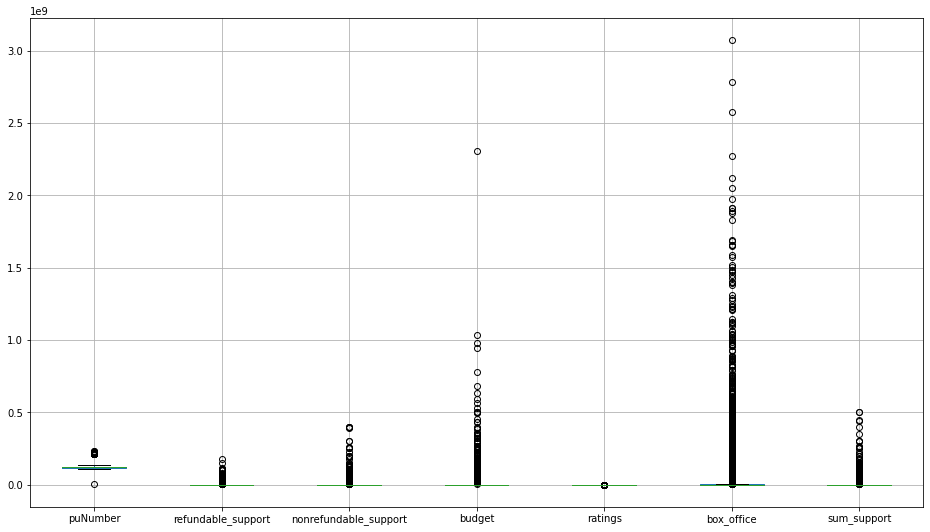

In [65]:
# Выводим на экран боксплот для всех количественных столбцов
df.boxplot(figsize=(16,9))

Тело боксплота почти нет для всех столбцов кроме столбцов `puNumber` и `ratings`. Можно сделать вывод что не имеются данные для `Q1`, `Q2`, `Q3` в столбцах где тело боксплота очень маленькое. Следовательно, проблема именно в том, что мы из-за большого количества выбросов(аномальных значений) мы не можем рассмотреть `Q1`, `Q2`, `Q3`.